## EDA

In [1]:
import pandas as pd

df = pd.read_csv("data/housing.csv")


print("Antal rader/kolumner:", df.shape)
display(df.head())
display(df.info())
print(f"Antal tomma: \n{df.isna().sum()}")


Antal rader/kolumner: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None

Antal tomma: 
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [2]:
top_20_pct = df["median_house_value"].quantile(0.8) # 80% av datan ligger under detta värde. Alltså enbart 20% av husen är dyrare än detta värde.

print(f"{top_20_pct:,} \n")


df["high_value"] = (df["median_house_value"] >= top_20_pct).astype(int) # skapar en ny kolumn "high_value" kollar om "mhv" är >= 290 000. 1 om det är >= 290k annars 0.


display(
    pd.DataFrame({
        "median_house_value": df["median_house_value"].head(7),
        "threshold": top_20_pct,
        "high_value": df["high_value"].head(7)
    })
)


print(f"{df["high_value"].value_counts()}\n")
print(f"Här ser vi att det finns {df["high_value"].value_counts()[1]:,} st områden där medianpriset överstiger thresholden.")


290,000.0 



,median_house_value,threshold,high_value
0,452600.0,290000.0,1
1,358500.0,290000.0,1
2,352100.0,290000.0,1
3,341300.0,290000.0,1
4,342200.0,290000.0,1
5,269700.0,290000.0,0
6,299200.0,290000.0,1


high_value
0    16510
1     4130
Name: count, dtype: int64

Här ser vi att det finns 4,130 st områden där medianpriset överstiger thresholden.


In [3]:
X_full = df.drop(columns=["median_house_value","high_value"]) # tar bort kolumnerna "median_house_value" & "high_value"
y_full = df["high_value"] # sätter target till enbart kolumnen "high_value"


display(X_full.head()) #kollar så kolumnerna har försvunnit ifrån "X_full"
display(y_full.head(7)) #kollar så target enbart är binär

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


0    1
1    1
2    1
3    1
4    1
5    0
6    1
Name: high_value, dtype: int64

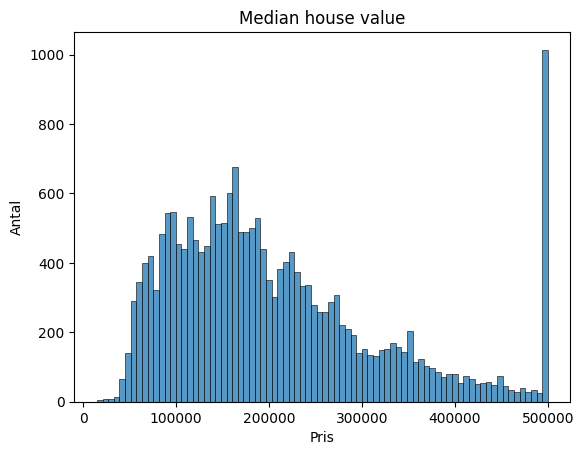

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(df["median_house_value"], bins=80)
plt.title("Median house value")
plt.xlabel("Pris")
plt.ylabel("Antal")
plt.show()

Histogrammet visar att median_house_value är högerskevt fördelad. Det finns många områden med ett exakt värde på 500 000. Detta tyder på att områden med ett faktiskt högre medianvärde än detta fortfarande registreras som maxvärdet 500 000.
Eftersom gränsen för high_value (290 000) ligger under 500 000 påverkas klassificering inte lika mycket som regression.

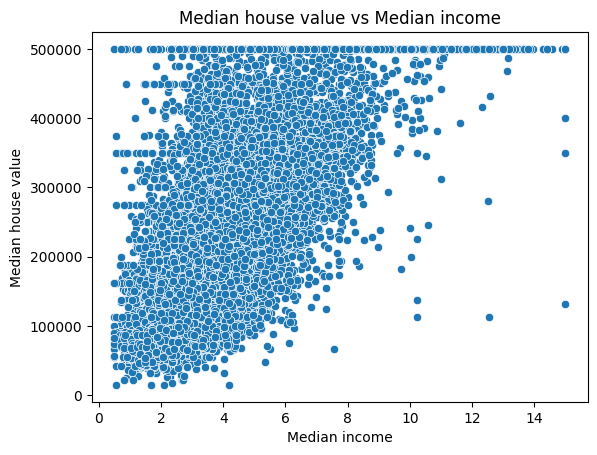

In [5]:
plt.figure()
sns.scatterplot(x= df["median_income"], y= df["median_house_value"])
plt.title("Median house value vs Median income")
plt.xlabel("Median income")
plt.ylabel("Median house value")
plt.show()

Scatterplotten visar ett positivt samband mellan median_income och median_house_value. Högre inkomst verkar kunna förklara en del av högre bostadspriser. Dock finns det en större spridning vilket tyder på att det finns flera faktorer som påverkar priset. Samma sak här ser man att det finns ett maxtak vid 500 000.

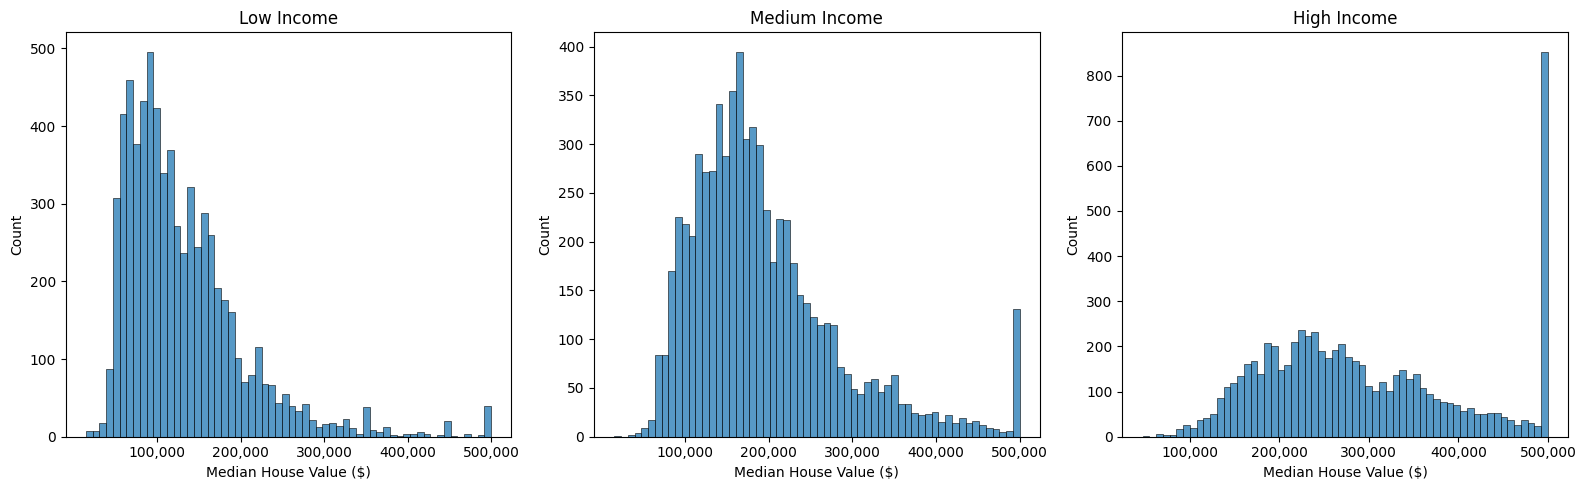

In [6]:

# skapar en ny kolumn "income_group" där varje rad antingen blir low, medium eller high baserat på fördelning av "median_income". 33% i low, 33% i medium, 33% i high.
df["income_group"] = pd.qcut(df["median_income"], q=3, labels=["Low", "Medium", "High"])


groups = ["Low", "Medium", "High"]


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, group in enumerate(groups):
    grouped_data = df[df["income_group"] == group]
    
    sns.histplot(grouped_data["median_house_value"], bins=60, ax=axes[i])
    
    axes[i].set_title(f"{group} Income")
    axes[i].set_xlabel("Median House Value ($)")
    axes[i].set_ylabel("Count")


x_values = range(100000, 600000, 100000)
x_ticks = [f"{val:,}" for val in x_values]
for ax in axes:
    ax.set_xticks(x_values)
    ax.set_xticklabels(x_ticks)



plt.tight_layout()
plt.show()

Genom att dela upp median_income i 3 lika stora grupper ser man att fördelningen av median_house_value förskjuts åt höger när inkomsten ökar.
Det framgår också tydligt att gruppen med hög inkomst har störst andel observationer vid maxvärdet 500 000. Detta tyder på att median_income är en viktig faktor för högre bostadspriser.

## Split

In [7]:
from sklearn.model_selection import train_test_split


# jag gör splitten innan jag fyller i NaN värden med t.ex. median. Jag vill inte räkna ut medianen med test datan. Annars får jag ju information om medianen ifrån testdatan.
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size= 0.2,
    random_state= 42,
    stratify= y_full # kör stratify så vi får rätt klassfördelning i både y_train & y_test
)

# kollar så datan ser korrekt uppdelad ut
print("X_train:", X_train.shape) 
print("X_test", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 9)
X_test (4128, 9)
y_train: (16512,)
y_test: (4128,)


## Preprocessing

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression


# delar upp features i numerisk och kategorisk för att kunna skala och hantera kolumen "ocean_proximity" korrekt.
numeric_features = X_train.select_dtypes(include= "number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy= "median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy= "most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num",numeric_transformer,numeric_features),
    ("cat",categorical_transformer, categorical_features)
])


## Baseline

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score


baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])


cv_strategy = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42) # kör en stratifiedKFold så att alla folds får samma klassfördelning (80/20)


# gör en dict för att förenkla cross_val_score för varje modell
cv_test = {
    "X": X_train,
    "y": y_train,
    "cv":cv_strategy,
    "scoring": "f1"     
}
# valde f1 som score pga den väger in både precision och recall


bl_scores = cross_val_score(baseline_model, **cv_test)


# gör en funktion med en loop för att enklare kunna skriva ut info om varje modell
def print_cv_results(to_print_dict):
    for name, model_scores in to_print_dict.items():
            print(name)
            print("f1 för varje fold:", model_scores.round(3))
            print("Medelvärdet för alla 5 folds:",model_scores.mean().round(3))
            print("Standardavvikelse:", model_scores.std().round(3),"\n")



print_cv_results({"Baseline:": bl_scores})


Baseline:
f1 för varje fold: [0.705 0.691 0.693 0.728 0.664]
Medelvärdet för alla 5 folds: 0.696
Standardavvikelse: 0.021 



## Modellering

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier



rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])


rf_scores =  cross_val_score(rf_model, **cv_test)
knn_scores = cross_val_score(knn_model, **cv_test)



to_print = {
    "Baseline (LogReg):" : bl_scores,
    "RandomForest:": rf_scores,
    "KNN:": knn_scores
}


print_cv_results(to_print)



# for name, model_scores in to_print.items():
#     print(name)
#     print("f1 för varje fold:", model_scores.round(3))
#     print("Medelvärdet för alla 5 folds:",model_scores.mean().round(3))
#     print("Standardavvikelse:", model_scores.std().round(3),"\n")




# print("Baseline (LogReg):")
# print("f1 för varje fold:", scores.round(3))
# print("Medelvärdet för alla 5 folds:",scores.mean().round(3))
# print("Standardavvikelse:", scores.std().round(3),"\n")


# print("RandomForest:")
# print("f1 för varje fold:", rf_scores.round(3))
# print("Medelvärdet för alla 5 folds:",rf_scores.mean().round(3))
# print("Standardavvikelse:", rf_scores.std().round(3),"\n")


# print("KNN:")
# print("f1 för varje fold:", knn_scores.round(3))
# print("Medelvärdet för alla 5 folds:",knn_scores.mean().round(3))
# print("Standardavvikelse:", knn_scores.std().round(3))

Baseline (LogReg):
f1 för varje fold: [0.705 0.691 0.693 0.728 0.664]
Medelvärdet för alla 5 folds: 0.696
Standardavvikelse: 0.021 

RandomForest:
f1 för varje fold: [0.812 0.779 0.76  0.803 0.772]
Medelvärdet för alla 5 folds: 0.785
Standardavvikelse: 0.02 

KNN:
f1 för varje fold: [0.689 0.685 0.688 0.714 0.684]
Medelvärdet för alla 5 folds: 0.692
Standardavvikelse: 0.011 

